# NV Diamond Pulse Data Analysis

This notebook analyzes new measurement data from `.npy` files in the `Avg_npy_pulse` folder. Each file corresponds to one crystallographic direction in an NV- 100 faced diamond. The notebook will:
- Examine the data structure and determine the number of pixels
- Visualize time traces for each pixel and direction
- Reconstruct the 2D pixel grid (zig-zag order)
- Visualize the spatial distribution at selected time points

**Data structure:**
- Each `.npy` file: 2D array, first column is time (seconds), remaining columns are pixel voltages (units: volts or as specified)
- Four files: one per crystallographic direction


In [31]:
# Import Required Libraries and Set Up Paths
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

# Set the folder path containing the .npy files
folder = 'Avg_npy_pulse'

# List all .npy files (one per crystallographic direction)
npy_files = sorted(glob.glob(os.path.join(folder, 'Pulse_avg_d*.npy')))
print('Found files:', npy_files)


Found files: ['Avg_npy_pulse/Pulse_avg_d1.npy', 'Avg_npy_pulse/Pulse_avg_d2.npy', 'Avg_npy_pulse/Pulse_avg_d3.npy', 'Avg_npy_pulse/Pulse_avg_d4.npy']


## Load and Inspect Data Files

Load each .npy file, print its shape, and display the first few rows to understand the structure. Confirm that the first column is time and the rest are pixel voltages.

In [32]:
# Load each .npy file, print shape and first few rows
all_data = []
for f in npy_files:
    arr = np.load(f)
    print(f"File: {os.path.basename(f)} | Shape: {arr.shape}")
    print("First 3 rows:\n", arr[:3])
    all_data.append(arr)
    print("---")
# Confirm: arr[:, 0] is time, arr[:, 1:] are pixel voltages

File: Pulse_avg_d1.npy | Shape: (457, 962)
First 3 rows:
 [[ 0.00000000e+00  7.94575342e+01  9.79260173e+01 ...  5.02662066e+01
   1.83949340e+02  2.60874027e+02]
 [ 3.86400000e-04  6.97000215e+01  7.90484173e+01 ...  5.74127265e+01
   1.92701682e+02  2.00465708e+02]
 [ 7.72800000e-04  6.78735524e+01  1.19341061e+02 ... -2.67764658e+01
   1.81571253e+02  2.52918467e+02]]
---
File: Pulse_avg_d2.npy | Shape: (457, 962)
First 3 rows:
 [[0.00000000e+00 1.40353527e+01 4.02364506e+00 ... 6.39354888e+01
  4.24899231e+01 1.02095369e+02]
 [3.86400000e-04 2.03529379e+01 2.75272821e+01 ... 4.39097611e+01
  1.35727491e+02 1.21714107e+02]
 [7.72800000e-04 2.02419408e+01 3.76465182e+01 ... 3.91368855e+01
  1.41268097e+02 1.45217744e+02]]
---
File: Pulse_avg_d3.npy | Shape: (457, 962)
First 3 rows:
 [[ 0.00000000e+00  4.67520757e+00 -3.00801733e+01 ...  3.49169467e+01
  -2.23777305e+01 -1.00303526e+02]
 [ 3.86400000e-04 -6.49443985e+01 -8.37931891e+00 ... -1.02534836e+01
  -8.51367373e+00 -1.01528025

## Determine Number of Pixels and Data Shape

For one file, extract the number of pixels by checking the number of columns minus one (for time). Print the number of pixels and check if it matches 31x31. Print the time vector shape and pixel trace shape.

In [33]:
# Analyze shape for one file (first direction)
arr = all_data[0]
time = arr[:, 0]
traces = arr[:, 1:]
n_timepoints, n_pixels = traces.shape
print(f"Number of pixels: {n_pixels}")
print(f"Is it a square? sqrt({n_pixels}) = {np.sqrt(n_pixels)}")
print(f"Time vector shape: {time.shape}")
print(f"Pixel traces shape: {traces.shape}")

Number of pixels: 961
Is it a square? sqrt(961) = 31.0
Time vector shape: (457,)
Pixel traces shape: (457, 961)


In [34]:
# Extract time and voltage matrices from the loaded files

time = all_data[0][:, 0]

voltage_d1 = all_data[0][:, 1:]
voltage_d2 = all_data[1][:, 1:]
voltage_d3 = all_data[2][:, 1:]
voltage_d4 = all_data[3][:, 1:]

print("time shape:", time.shape)
print("d1 shape:", voltage_d1.shape)
print("d2 shape:", voltage_d2.shape)
print("d3 shape:", voltage_d3.shape)
print("d4 shape:", voltage_d4.shape)

voltage_stack = np.stack([voltage_d1, voltage_d2, voltage_d3, voltage_d4], axis=0)

print("voltage_stack shape:", voltage_stack.shape)
print("Channel order: d1, d2, d3, d4")

time shape: (457,)
d1 shape: (457, 961)
d2 shape: (457, 961)
d3 shape: (457, 961)
d4 shape: (457, 961)
voltage_stack shape: (4, 457, 961)
Channel order: d1, d2, d3, d4


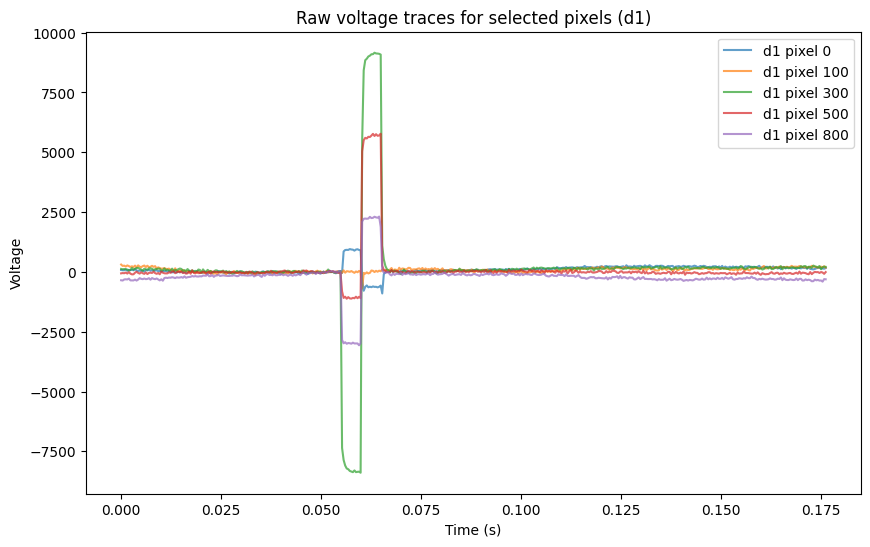

In [35]:
# Plot raw traces for a few example pixels
pixel_list = [0, 100, 300, 500, 800]

plt.figure(figsize=(10, 6))

for pixel_idx in pixel_list:
    plt.plot(time, voltage_d1[:, pixel_idx], alpha=0.7, label=f'd1 pixel {pixel_idx}')

plt.xlabel('Time (s)')
plt.ylabel('Voltage')
plt.title('Raw voltage traces for selected pixels (d1)')
plt.legend()
plt.show()

baseline subtraction


In [36]:
# Baseline subtraction using the first few time points
baseline_n = 20

baseline = np.mean(voltage_stack[:, :baseline_n, :], axis=1, keepdims=True)
delta_voltage = voltage_stack - baseline

print("baseline shape:", baseline.shape)
print("delta_voltage shape:", delta_voltage.shape)

baseline shape: (4, 1, 961)
delta_voltage shape: (4, 457, 961)


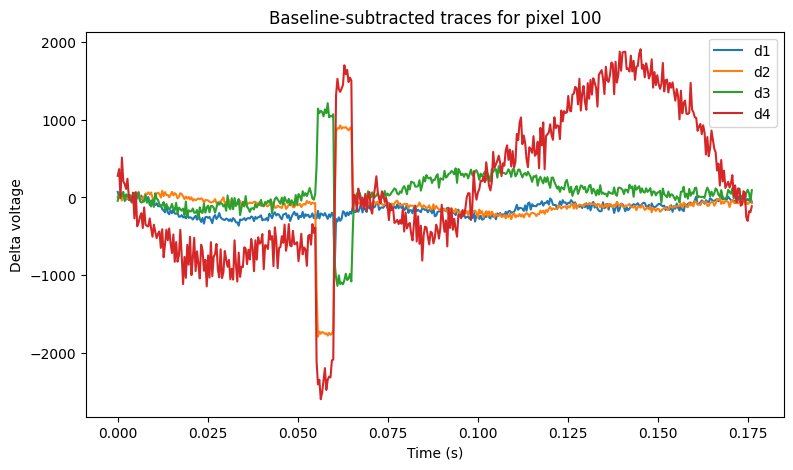

In [37]:
# Plot baseline-subtracted traces for one pixel
pixel_idx = 100

plt.figure(figsize=(9, 5))
plt.plot(time, delta_voltage[0, :, pixel_idx], label='d1')
plt.plot(time, delta_voltage[1, :, pixel_idx], label='d2')
plt.plot(time, delta_voltage[2, :, pixel_idx], label='d3')
plt.plot(time, delta_voltage[3, :, pixel_idx], label='d4')
plt.xlabel('Time (s)')
plt.ylabel('Delta voltage')
plt.title(f'Baseline-subtracted traces for pixel {pixel_idx}')
plt.legend()
plt.show()

In [38]:
# --- Set pixel index and time indices for analysis ---
pixel_idx = 100  # pixel to analyze

t1 = 0.0005  # time in seconds for first interval
nt2 = 0.0015  # time in seconds for second interval

# Find the closest indices in the time array
time_idx_pos = (np.abs(time - t1)).argmin()
time_idx_neg = (np.abs(time - nt2)).argmin()

print(f"Selected pixel: {pixel_idx}")
print(f"t1 = {t1} s (index {time_idx_pos})")
print(f"t2 = {nt2} s (index {time_idx_neg})")


Selected pixel: 100
t1 = 0.0005 s (index 1)
t2 = 0.0015 s (index 4)


## reconstruct greed



In [39]:
# Reconstruct the 2D pixel grid from 1D pixel index
grid_size = int(np.sqrt(n_pixels))
grid = np.zeros((grid_size, grid_size), dtype=int)

for idx in range(n_pixels):
    col = idx // grid_size
    row = idx % grid_size

    if col % 2 == 0:
        grid[grid_size - 1 - row, grid_size - 1 - col] = idx
    else:
        grid[row, grid_size - 1 - col] = idx

print("Grid mapping (pixel indices):")
print(grid)

Grid mapping (pixel indices):
[[960 899 898 837 836 775 774 713 712 651 650 589 588 527 526 465 464 403
  402 341 340 279 278 217 216 155 154  93  92  31  30]
 [959 900 897 838 835 776 773 714 711 652 649 590 587 528 525 466 463 404
  401 342 339 280 277 218 215 156 153  94  91  32  29]
 [958 901 896 839 834 777 772 715 710 653 648 591 586 529 524 467 462 405
  400 343 338 281 276 219 214 157 152  95  90  33  28]
 [957 902 895 840 833 778 771 716 709 654 647 592 585 530 523 468 461 406
  399 344 337 282 275 220 213 158 151  96  89  34  27]
 [956 903 894 841 832 779 770 717 708 655 646 593 584 531 522 469 460 407
  398 345 336 283 274 221 212 159 150  97  88  35  26]
 [955 904 893 842 831 780 769 718 707 656 645 594 583 532 521 470 459 408
  397 346 335 284 273 222 211 160 149  98  87  36  25]
 [954 905 892 843 830 781 768 719 706 657 644 595 582 533 520 471 458 409
  396 347 334 285 272 223 210 161 148  99  86  37  24]
 [953 906 891 844 829 782 767 720 705 658 643 596 581 534 519 472 4

In [40]:
import pandas as pd

results_df = pd.read_csv("results.csv")
A_results_df = pd.read_csv("A_results.csv")

display(results_df.head(20))
display(A_results_df.head(20))

,group,name,value
0,operating_point,Bx0_mT,0.431051
1,operating_point,By0_mT,3.103259
2,operating_point,Bz0_mT,0.360538
3,operating_point,B0_norm_mT,3.153729
4,operating_point,D_fit_MHz,2867.204880
5,operating_point,Mz_d1_MHz,-0.116911
6,operating_point,Mz_d2_MHz,-0.015133
7,operating_point,Mz_d3_MHz,-0.197859
8,operating_point,Mz_d4_MHz,-0.097547
9,operating_point,fit_residual_norm_MHz,0.130536


,group,row,col,value,units
0,A_matrix,d1,Bx,0.3569841862827161,MHz_per_mT
1,A_matrix,d1,By,-22.163057112038587,MHz_per_mT
2,A_matrix,d1,Bz,-17.190345370408977,MHz_per_mT
3,A_matrix,d2,Bx,0.3556599010607897,MHz_per_mT
4,A_matrix,d2,By,-21.88186793478053,MHz_per_mT
5,A_matrix,d2,Bz,17.580839697529882,MHz_per_mT
6,A_matrix,d3,Bx,-22.81212502452945,MHz_per_mT
7,A_matrix,d3,By,2.4793270220015984,MHz_per_mT
8,A_matrix,d3,Bz,-16.086076296005558,MHz_per_mT
9,A_matrix,d4,Bx,-21.442500724560887,MHz_per_mT


In [41]:
axes_order = ["d1", "d2", "d3", "d4"]

A = np.zeros((4, 3), dtype=float)
A_plus = np.zeros((3, 4), dtype=float)

for i, ax in enumerate(axes_order):
    for j, comp in enumerate(["Bx", "By", "Bz"]):
        A[i, j] = float(
            A_results_df.loc[
                (A_results_df["group"] == "A_matrix") &
                (A_results_df["row"] == ax) &
                (A_results_df["col"] == comp),
                "value"
            ].iloc[0]
        )

for i, comp in enumerate(["Bx", "By", "Bz"]):
    for j, ax in enumerate(axes_order):
        A_plus[i, j] = float(
            A_results_df.loc[
                (A_results_df["group"] == "A_plus") &
                (A_results_df["row"] == comp) &
                (A_results_df["col"] == ax),
                "value"
            ].iloc[0]
        )

print("A shape:", A.shape)
print("A_plus shape:", A_plus.shape)

A_df = pd.DataFrame(A, index=axes_order, columns=["Bx", "By", "Bz"])
Aplus_df = pd.DataFrame(A_plus, index=["Bx", "By", "Bz"], columns=axes_order)

display(A_df)
display(Aplus_df)

A shape: (4, 3)
A_plus shape: (3, 4)


,Bx,By,Bz
d1,0.356984,-22.163057,-17.190345
d2,0.355660,-21.881868,17.580840
d3,-22.812125,2.479327,-16.086076
d4,-21.442501,2.275476,15.650009


,d1,d2,d3,d4
Bx,-0.001968,-0.002926,-0.022872,-0.022384
By,-0.022954,-0.022530,-0.000408,-0.000322
Bz,-0.015620,0.015784,-0.013867,0.014755


In [42]:
f_left_centers_mhz = np.array([
    float(results_df.loc[results_df["name"] == "d1_f_left_meas_MHz", "value"].iloc[0]),
    float(results_df.loc[results_df["name"] == "d2_f_left_meas_MHz", "value"].iloc[0]),
    float(results_df.loc[results_df["name"] == "d3_f_left_meas_MHz", "value"].iloc[0]),
    float(results_df.loc[results_df["name"] == "d4_f_left_meas_MHz", "value"].iloc[0]),
], dtype=float)

print("Tracked lower-transition centers [MHz]:", f_left_centers_mhz)

Tracked lower-transition centers [MHz]: [2791.20577148 2803.93502334 2855.26217136 2866.88305566]


In [43]:
odmr_csv_path = "/home/vita/projects/NV_sensing/data/ODMR_avg_99-6dBm_0mW.csv"

odmr_df = pd.read_csv(odmr_csv_path, sep=r"\s+")
odmr_df.columns = [c.strip() for c in odmr_df.columns]

freq_col = [c for c in odmr_df.columns if "freq" in c.lower()][0]
sig_col = [c for c in odmr_df.columns if c != freq_col][0]

f_hz_odmr = odmr_df[freq_col].to_numpy(dtype=float)
y_raw_odmr = odmr_df[sig_col].to_numpy(dtype=float)

idx = np.argsort(f_hz_odmr)
f_hz_odmr = f_hz_odmr[idx]
y_raw_odmr = y_raw_odmr[idx]

f_mhz_odmr = f_hz_odmr / 1e6
f_ghz_odmr = f_hz_odmr / 1e9

print("ODMR points:", len(f_mhz_odmr))
print("Frequency range [GHz]:", f_ghz_odmr.min(), "to", f_ghz_odmr.max())

ODMR points: 1000
Frequency range [GHz]: 2.77 to 2.9698


baseline_odmr = 0.07800472
S_odmr min/max = 0.8418208539175578 1.0033623606366384


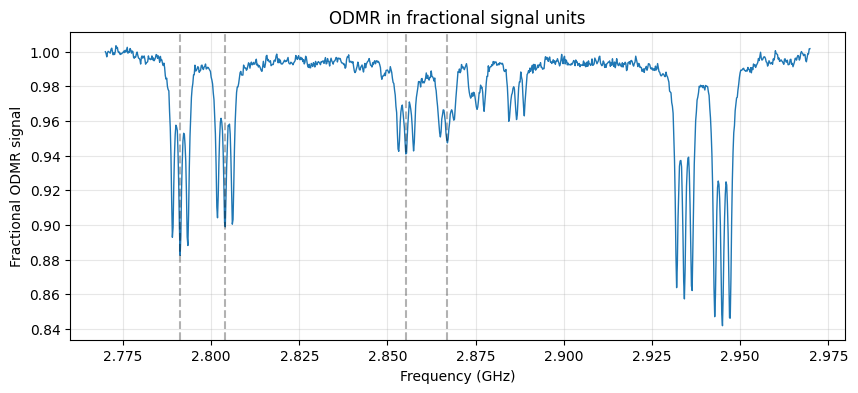

In [44]:
# Off-resonant baseline estimate from the top 5% of ODMR signal values
n_top = max(10, len(y_raw_odmr) // 20)
baseline_odmr = np.mean(np.sort(y_raw_odmr)[-n_top:])

S_odmr = y_raw_odmr / baseline_odmr

print("baseline_odmr =", baseline_odmr)
print("S_odmr min/max =", S_odmr.min(), S_odmr.max())

plt.figure(figsize=(10, 4))
plt.plot(f_ghz_odmr, S_odmr, lw=1)
for c in f_left_centers_mhz:
    plt.axvline(c / 1000.0, color="k", ls="--", alpha=0.3)
plt.xlabel("Frequency (GHz)")
plt.ylabel("Fractional ODMR signal")
plt.title("ODMR in fractional signal units")
plt.grid(True, alpha=0.3)
plt.show()

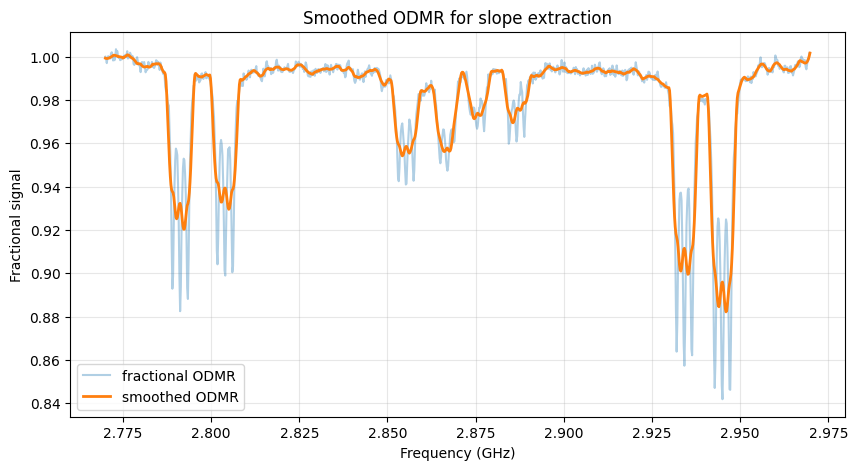

In [45]:
from scipy.signal import savgol_filter

df_mhz = np.mean(np.diff(f_mhz_odmr))

S_odmr_smooth = savgol_filter(S_odmr, window_length=21, polyorder=3)
dS_dnu = savgol_filter(S_odmr, window_length=21, polyorder=3, deriv=1, delta=df_mhz)

plt.figure(figsize=(10, 5))
plt.plot(f_ghz_odmr, S_odmr, alpha=0.35, label="fractional ODMR")
plt.plot(f_ghz_odmr, S_odmr_smooth, lw=2, label="smoothed ODMR")
plt.xlabel("Frequency (GHz)")
plt.ylabel("Fractional signal")
plt.title("Smoothed ODMR for slope extraction")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [46]:
offset_mhz = 0.6   # move left of the fitted center
window_mhz = 0.25  # small averaging window around that point

slope_rows = []

for i, ax in enumerate(axes_order):
    center = f_left_centers_mhz[i]
    target_freq = center - offset_mhz

    mask = (f_mhz_odmr >= target_freq - window_mhz) & (f_mhz_odmr <= target_freq + window_mhz)

    local_freq = f_mhz_odmr[mask]
    local_smooth = S_odmr_smooth[mask]
    local_slope = dS_dnu[mask]

    slope_mean = np.mean(local_slope)
    slope_rows.append({
        "axis": ax,
        "center_MHz": center,
        "target_left_slope_freq_MHz": target_freq,
        "slope_fraction_per_MHz": slope_mean
    })

slopes_df = pd.DataFrame(slope_rows)
display(slopes_df)

,axis,center_MHz,target_left_slope_freq_MHz,slope_fraction_per_MHz
0,d1,2791.205771,2790.605771,-0.014559
1,d2,2803.935023,2803.335023,-0.012921
2,d3,2855.262171,2854.662171,-0.004828
3,d4,2866.883056,2866.283056,-0.003832


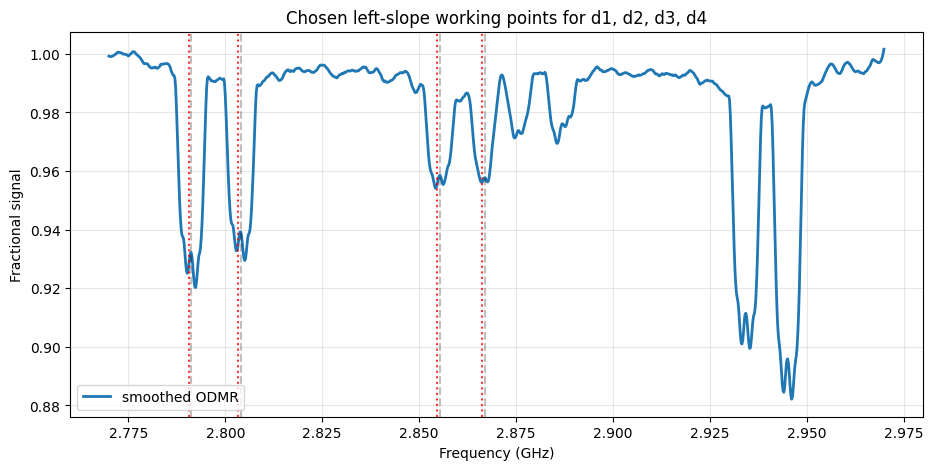

In [47]:
plt.figure(figsize=(11, 5))
plt.plot(f_ghz_odmr, S_odmr_smooth, lw=2, label="smoothed ODMR")

for _, row in slopes_df.iterrows():
    target = row["target_left_slope_freq_MHz"] / 1000.0
    center = row["center_MHz"] / 1000.0
    plt.axvline(center, color="k", ls="--", alpha=0.25)
    plt.axvline(target, color="red", ls=":", alpha=0.8)

plt.xlabel("Frequency (GHz)")
plt.ylabel("Fractional signal")
plt.title("Chosen left-slope working points for d1, d2, d3, d4")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [48]:
slopes_fraction_per_MHz = slopes_df["slope_fraction_per_MHz"].to_numpy(dtype=float)

print("Slopes in channel order [d1,d2,d3,d4]:")
print(slopes_fraction_per_MHz)

Slopes in channel order [d1,d2,d3,d4]:
[-0.01455897 -0.01292102 -0.00482801 -0.00383216]


In [49]:
baseline_n = 20

baseline_voltage = np.mean(voltage_stack[:, :baseline_n, :], axis=1, keepdims=True)

# Fractional pulse signal relative to baseline:
# S(t) = V(t)/V0
fractional_signal = voltage_stack / baseline_voltage

# Fractional change relative to baseline:
# ΔS = (V - V0)/V0
delta_fractional_signal = fractional_signal - 1.0

print("baseline_voltage shape:", baseline_voltage.shape)
print("fractional_signal shape:", fractional_signal.shape)
print("delta_fractional_signal shape:", delta_fractional_signal.shape)

baseline_voltage shape: (4, 1, 961)
fractional_signal shape: (4, 457, 961)
delta_fractional_signal shape: (4, 457, 961)


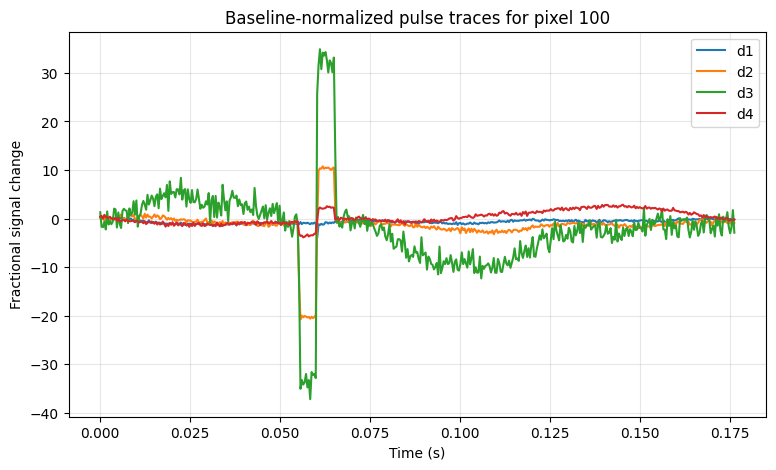

In [50]:
pixel_idx = 100

plt.figure(figsize=(9, 5))
plt.plot(time, delta_fractional_signal[0, :, pixel_idx], label='d1')
plt.plot(time, delta_fractional_signal[1, :, pixel_idx], label='d2')
plt.plot(time, delta_fractional_signal[2, :, pixel_idx], label='d3')
plt.plot(time, delta_fractional_signal[3, :, pixel_idx], label='d4')
plt.xlabel('Time (s)')
plt.ylabel('Fractional signal change')
plt.title(f'Baseline-normalized pulse traces for pixel {pixel_idx}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

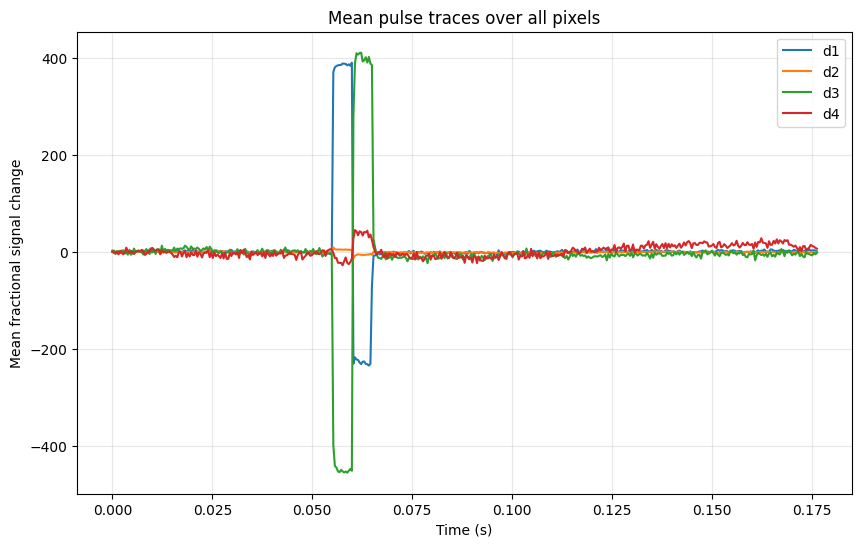

In [51]:
mean_fractional_traces = np.mean(delta_fractional_signal, axis=2)

plt.figure(figsize=(10, 6))
for i, ax_name in enumerate(axes_order):
    plt.plot(time, mean_fractional_traces[i], label=ax_name)

plt.xlabel("Time (s)")
plt.ylabel("Mean fractional signal change")
plt.title("Mean pulse traces over all pixels")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Positive window contains 1 time points
Negative window contains 1 time points


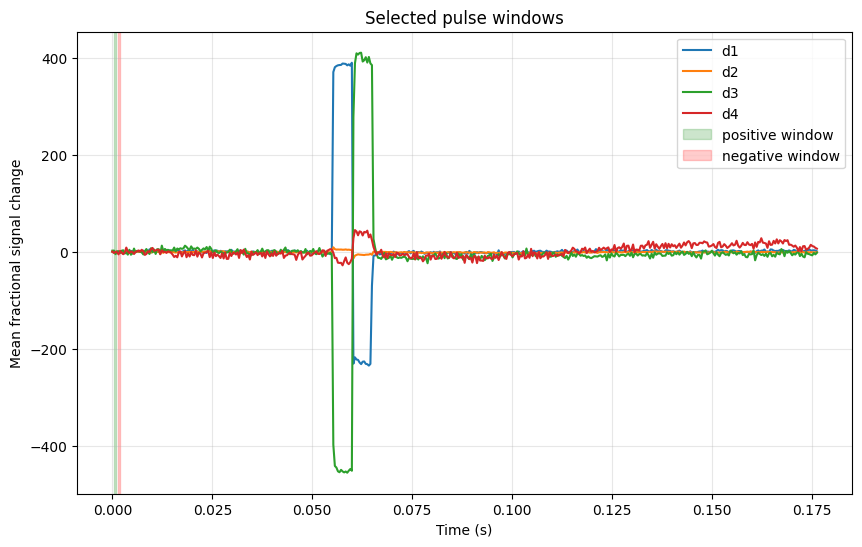

In [52]:
t_pos_start = 0.0004
t_pos_end   = 0.0009

t_neg_start = 0.0013
t_neg_end   = 0.0018

mask_pos = (time >= t_pos_start) & (time <= t_pos_end)
mask_neg = (time >= t_neg_start) & (time <= t_neg_end)

print("Positive window contains", np.sum(mask_pos), "time points")
print("Negative window contains", np.sum(mask_neg), "time points")

plt.figure(figsize=(10, 6))
for i, ax_name in enumerate(axes_order):
    plt.plot(time, mean_fractional_traces[i], label=ax_name)

plt.axvspan(t_pos_start, t_pos_end, color="green", alpha=0.2, label="positive window")
plt.axvspan(t_neg_start, t_neg_end, color="red", alpha=0.2, label="negative window")

plt.xlabel("Time (s)")
plt.ylabel("Mean fractional signal change")
plt.title("Selected pulse windows")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [53]:
deltaS_pos = np.mean(delta_fractional_signal[:, mask_pos, :], axis=1)   # shape (4, 961)
deltaS_neg = np.mean(delta_fractional_signal[:, mask_neg, :], axis=1)   # shape (4, 961)

print("deltaS_pos shape:", deltaS_pos.shape)
print("deltaS_neg shape:", deltaS_neg.shape)

deltaNu_pos = deltaS_pos / slopes_fraction_per_MHz[:, None]   # MHz
deltaNu_neg = deltaS_neg / slopes_fraction_per_MHz[:, None]   # MHz

print("deltaNu_pos shape:", deltaNu_pos.shape)
print("deltaNu_neg shape:", deltaNu_neg.shape)

deltaS_pos shape: (4, 961)
deltaS_neg shape: (4, 961)
deltaNu_pos shape: (4, 961)
deltaNu_neg shape: (4, 961)


In [54]:
B_pos = A_plus @ deltaNu_pos   # shape (3, 961), units mT
B_neg = A_plus @ deltaNu_neg   # shape (3, 961), units mT

print("B_pos shape:", B_pos.shape)
print("B_neg shape:", B_neg.shape)

B_pos shape: (3, 961)
B_neg shape: (3, 961)


In [55]:
Bx_pos_map = B_pos[0, grid]
By_pos_map = B_pos[1, grid]
Bz_pos_map = B_pos[2, grid]

Bx_neg_map = B_neg[0, grid]
By_neg_map = B_neg[1, grid]
Bz_neg_map = B_neg[2, grid]

Bmag_pos_map = np.sqrt(Bx_pos_map**2 + By_pos_map**2 + Bz_pos_map**2)
Bmag_neg_map = np.sqrt(Bx_neg_map**2 + By_neg_map**2 + Bz_neg_map**2)

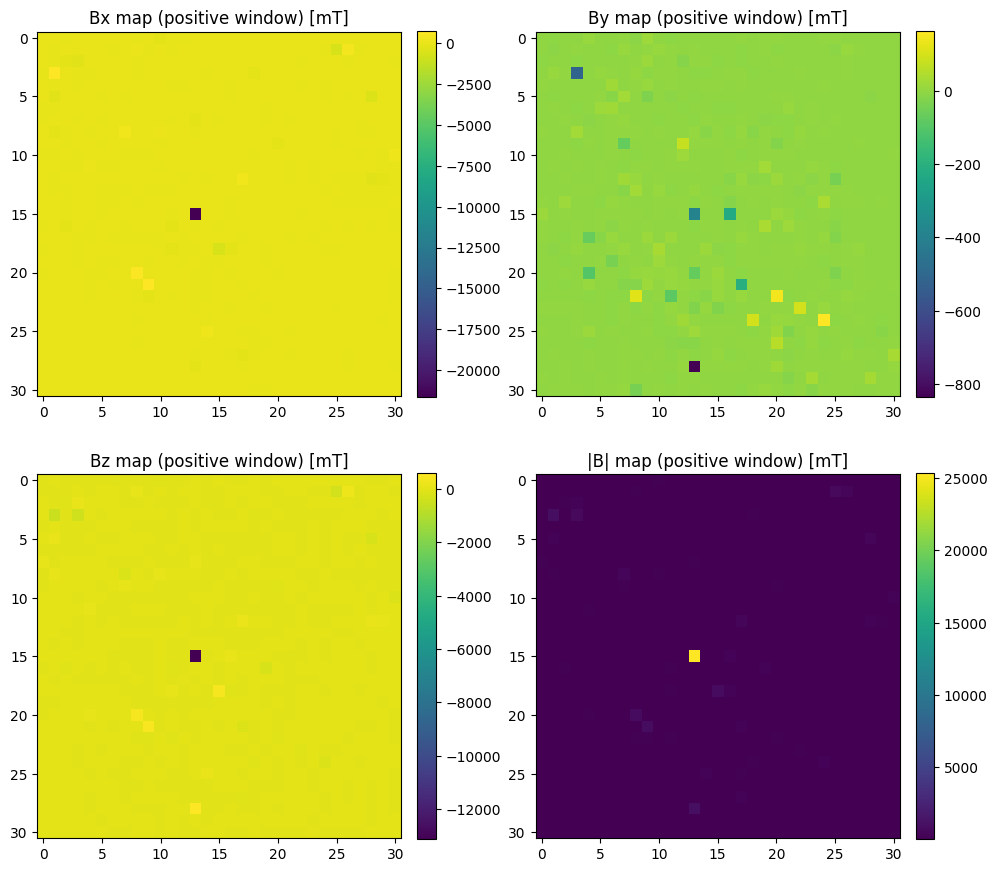

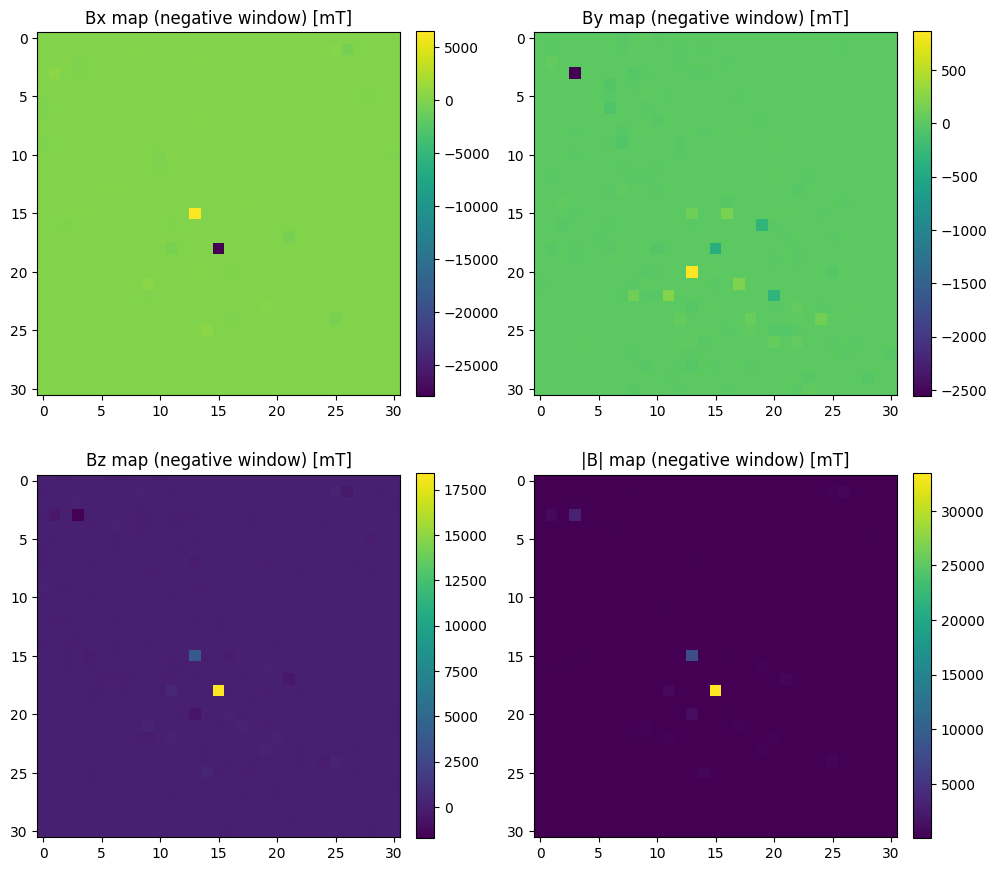

In [56]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9))

im0 = axes[0, 0].imshow(Bx_pos_map)
axes[0, 0].set_title("Bx map (positive window) [mT]")
plt.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04)

im1 = axes[0, 1].imshow(By_pos_map)
axes[0, 1].set_title("By map (positive window) [mT]")
plt.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)

im2 = axes[1, 0].imshow(Bz_pos_map)
axes[1, 0].set_title("Bz map (positive window) [mT]")
plt.colorbar(im2, ax=axes[1, 0], fraction=0.046, pad=0.04)

im3 = axes[1, 1].imshow(Bmag_pos_map)
axes[1, 1].set_title("|B| map (positive window) [mT]")
plt.colorbar(im3, ax=axes[1, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(10, 9))

im0 = axes[0, 0].imshow(Bx_neg_map)
axes[0, 0].set_title("Bx map (negative window) [mT]")
plt.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04)

im1 = axes[0, 1].imshow(By_neg_map)
axes[0, 1].set_title("By map (negative window) [mT]")
plt.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)

im2 = axes[1, 0].imshow(Bz_neg_map)
axes[1, 0].set_title("Bz map (negative window) [mT]")
plt.colorbar(im2, ax=axes[1, 0], fraction=0.046, pad=0.04)

im3 = axes[1, 1].imshow(Bmag_neg_map)
axes[1, 1].set_title("|B| map (negative window) [mT]")
plt.colorbar(im3, ax=axes[1, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [57]:
deltaNu_full = delta_fractional_signal / slopes_fraction_per_MHz[:, None, None]   # MHz

B_full = np.einsum("ij,jtp->itp", A_plus, deltaNu_full)   # (3, time, pixel), mT
Bmag_full = np.sqrt(B_full[0]**2 + B_full[1]**2 + B_full[2]**2)

print("B_full shape:", B_full.shape)
print("Bmag_full shape:", Bmag_full.shape)

B_full shape: (3, 457, 961)
Bmag_full shape: (457, 961)


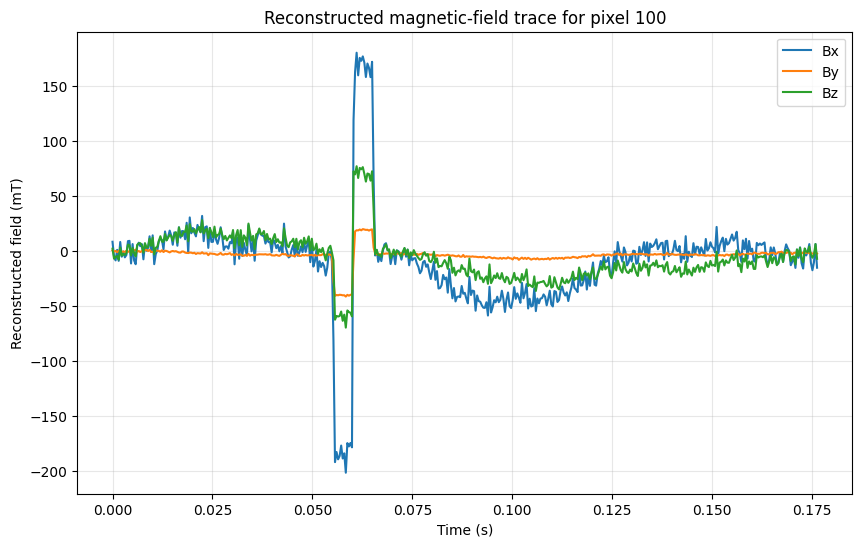

In [58]:
pixel_idx = 100

plt.figure(figsize=(10, 6))
plt.plot(time, B_full[0, :, pixel_idx], label="Bx")
plt.plot(time, B_full[1, :, pixel_idx], label="By")
plt.plot(time, B_full[2, :, pixel_idx], label="Bz")
plt.xlabel("Time (s)")
plt.ylabel("Reconstructed field (mT)")
plt.title(f"Reconstructed magnetic-field trace for pixel {pixel_idx}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()